In [12]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:

drinking_df = pd.read_csv("smoking_driking_dataset_Ver01.csv")
drinking_df

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y
991344,Male,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,1.0,N


In [14]:
num_duplicates = drinking_df.duplicated().sum()
num_total = drinking_df.shape[0]
num_unique = num_total - num_duplicates
print(f"Prosent beholdt: {(num_unique / num_total) * 100:.10f}%")
drinking_df_unique = drinking_df.drop_duplicates()

Prosent beholdt: 99.9973773032%


In [15]:
import numpy as np
import pandas as pd

df = drinking_df_unique.copy()

cat_cols = ["sex", "SMK_stat_type_cd", "DRK_YN", "urine_protein", "hear_left", "hear_right"]
no_log = ["SMK_stat_type_cd", "urine_protein", "hemoglobin", "hear_right", "hear_left", "weight", "height", "age"]

df_log = df.copy()

def transform_with_optional_log(df, col, allow_log=True):

    global df_log

    if col not in df.columns:
        return

    data = df[col].dropna()
    if data.empty:
        return

    if col in cat_cols:
        return

    if allow_log and (data > 0).all():
        log_series = np.log10(data)     
        df_log.loc[log_series.index, col] = log_series

for col in df.columns:
    allow_log = (col not in no_log and col not in cat_cols)
    transform_with_optional_log(df, col, allow_log=allow_log)



In [16]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

df = df_log.copy()

columns_to_check = [
    "age", "height", "weight", "waistline",
    "sight_left", "sight_right",
    "SBP", "DBP", "BLDS",
    "tot_chole", "HDL_chole", "LDL_chole", "triglyceride",
    "hemoglobin", "serum_creatinine", "SGOT_AST", "SGOT_ALT", "gamma_GTP",
]

# Beregn z-scores per kolonne (NaN ignoreres i sammenligningen under)
z_scores = df[columns_to_check].apply(zscore)

# Behold rader der alle valgte kolonner har |z| <= 3
mask = (np.abs(z_scores) <= 3).all(axis=1)
df_clean = df[mask].copy()

print(f"Rows before: {len(df)}, after outlier removal: {len(df_clean)}")

# df_clean er nå datasettet uten outliers etter z-score-kriteriet


Rows before: 991320, after outlier removal: 877018


In [17]:

df_clean["sex"] = df_clean["sex"].map({"Male": 0, "Female": 1})
df_clean["DRK_YN"] = df_clean["DRK_YN"].map({"N": 0, "Y": 1})

df_clean = df_clean.round(1)

df_clean.to_csv("drinking_df_encoded.csv", index=False)

print("done")

done


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --- 1) Les data ---
df = pd.read_csv("drinking_df_encoded.csv")

# Sikre numeriske typer der mulig
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="ignore")

# --- 2) Lag BMI og fjern height/weight ---
if {"height", "weight"}.issubset(df.columns):
    valid_h = pd.to_numeric(df["height"], errors="coerce") > 0
    df.loc[valid_h, "BMI"] = df.loc[valid_h, "weight"] / (df.loc[valid_h, "height"] / 100.0) ** 2
    df = df.drop(columns=["height", "weight"], errors="ignore")

# --- 3) Aldersgrupper → tall i [0,1] ---
bins   = [15, 24, 44, 66, 79, np.inf]              # 16–24, 25–44, 45–66, 67–79, 80+
labels = ["16-24", "25-44", "45-66", "67-79", "80+"]
if "age" in df.columns:
    age_cat = pd.cut(df["age"], bins=bins, labels=labels, include_lowest=True, right=True)
    idx_map = {lab: i for i, lab in enumerate(labels)}  # 0..4
    age_idx = age_cat.map(idx_map).astype(float)
    df["age_group_scaled"] = age_idx / (len(labels) - 1)  # → [0,1]
    df = df.drop(columns=["age"], errors="ignore")

# --- 4) Skaler alle andre numeriske kolonner til [0,1] (behold age_group_scaled som er ferdig skalert) ---
num_cols = df.select_dtypes(include=[float, int]).columns.tolist()
cols_to_scale = [c for c in num_cols if c != "age_group_scaled"]

if cols_to_scale:
    scaler = MinMaxScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# --- 5) Flytt DRK_YN (target) til siste kolonne ---
if "DRK_YN" in df.columns:
    df = df[[c for c in df.columns if c != "DRK_YN"] + ["DRK_YN"]]

# --- 6) Lagre ---
out_path = "drinking_df_bmi_agegroup_scaled.csv"
df.to_csv(out_path, index=False)
print(f"✅ Done -> {out_path}")



C:\Users\hanev\AppData\Local\Temp\ipykernel_19920\1573980676.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


✅ Done -> drinking_df_bmi_agegroup_scaled.csv


Antall komponenter som forklarer 95% av variansen: 16
✅ Lagret PCA-transformert data -> drinking_df_pca.csv


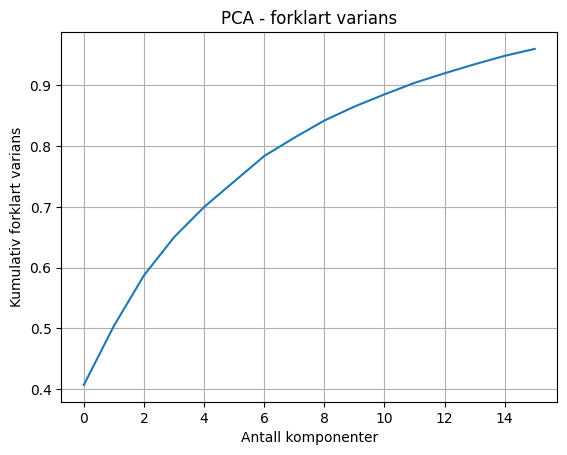

In [19]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Les datasettet etter at alt er skalert
df = pd.read_csv("drinking_df_bmi_agegroup_scaled.csv")

# Split features og target
X = df.drop(columns=["DRK_YN"])
y = df["DRK_YN"]

# Kjør PCA – behold f.eks. nok komponenter til å forklare 95 % av variansen
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Antall komponenter som forklarer 95% av variansen: {pca.n_components_}")

# Lag ny DataFrame med PCA-komponenter
pca_cols = [f"PC{i+1}" for i in range(pca.n_components_)]
df_pca = pd.DataFrame(X_pca, columns=pca_cols)
df_pca["DRK_YN"] = y.values

# Lagre
df_pca.to_csv("drinking_df_pca.csv", index=False)
print("✅ Lagret PCA-transformert data -> drinking_df_pca.csv")

# (valgfritt) Plott forklart varians
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Antall komponenter")
plt.ylabel("Kumulativ forklart varians")
plt.title("PCA - forklart varians")
plt.grid(True)
plt.show()


In [21]:
# GPU-ACCELERATED NN COMPARISON: BASE vs PCA (TensorFlow/Keras)
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ----------------------------
# 0) GPU check + mixed precision
# ----------------------------
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs found:", gpus)
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")  # FP16 on RTX 2080
    print("Mixed precision enabled (float16).")
except Exception as e:
    print("Mixed precision not enabled:", e)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# ----------------------------
# 1) Load base dataset
# ----------------------------
base_path = "drinking_df_bmi_agegroup_scaled.csv"
if not os.path.exists(base_path):
    raise FileNotFoundError(f"Missing {base_path}. Create it first.")

df = pd.read_csv(base_path)
if "DRK_YN" not in df.columns:
    raise ValueError("Target column 'DRK_YN' not found.")

y = df["DRK_YN"].astype(int).values
X_base = df.drop(columns=["DRK_YN"]).astype(np.float32).values  # already scaled in [0,1]

# ----------------------------
# 2) Build PCA dataset (95% var)
# ----------------------------
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_base).astype(np.float32)
print(f"PCA components kept: {X_pca.shape[1]} (95% variance)")

# ----------------------------
# 3) Use the same stratified split for fair comparison
# ----------------------------
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

Xb_train, Xb_test = X_base[idx_train], X_base[idx_test]
Xp_train, Xp_test = X_pca[idx_train],  X_pca[idx_test]
y_train, y_test   = y[idx_train],      y[idx_test]

# ----------------------------
# 4) Model builder
# ----------------------------
def build_model(input_dim, params):
    """
    params dict keys:
      - layers: tuple of hidden units, e.g. (128,64)
      - activation: "relu" or "tanh"
      - dropout: float in [0, 0.5]
      - lr: learning rate
      - l2: L2 weight decay
    """
    reg = keras.regularizers.l2(params["l2"]) if params["l2"] > 0 else None
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in params["layers"]:
        model.add(layers.Dense(units, activation=params["activation"], kernel_regularizer=reg))
        if params["dropout"] > 0:
            model.add(layers.Dropout(params["dropout"]))
    # Binary output
    model.add(layers.Dense(1, activation="sigmoid", dtype="float32"))  # force float32 output for metrics
    opt = keras.optimizers.Adam(learning_rate=params["lr"])
    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ----------------------------
# 5) Hyperparameter search (random)
# ----------------------------
def random_param_sets(n):
    rng = np.random.RandomState(RANDOM_STATE)
    layer_choices = [
        (64,), (128,), (256,),
        (128,64), (256,128),
        (128,64,32)
    ]
    activations = ["relu", "tanh"]
    dropouts = [0.0, 0.1, 0.2, 0.3, 0.4]
    lrs = np.logspace(np.log10(1e-4), np.log10(5e-3), 6)   # 1e-4 .. 5e-3
    l2s = [0.0, 1e-6, 1e-5, 1e-4]
    batches = [32, 64, 128, 256]
    out = []
    for _ in range(n):
        out.append({
            "layers": layer_choices[rng.randint(len(layer_choices))],
            "activation": activations[rng.randint(len(activations))],
            "dropout": dropouts[rng.randint(len(dropouts))],
            "lr": float(lrs[rng.randint(len(lrs))]),
            "l2": float(l2s[rng.randint(len(l2s))]),
            "batch": int(batches[rng.randint(len(batches))]),
            "epochs": 200,
        })
    return out

param_candidates = random_param_sets(25)  # øk til 50+ for grundigere søk

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    mode="max",
    restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

def tune_and_eval(Xtr, ytr, Xte, yte, label):
    best_val_acc = -np.inf
    best_hist = None
    best_params = None
    best_model = None

    for i, p in enumerate(param_candidates, 1):
        model = build_model(Xtr.shape[1], p)
        hist = model.fit(
            Xtr, ytr,
            validation_split=0.2,
            epochs=p["epochs"],
            batch_size=p["batch"],
            verbose=0,
            callbacks=[early_stop, reduce_lr],
            shuffle=True
        )
        val_acc = max(hist.history["val_accuracy"])
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_hist = hist
            best_params = p
            best_model = model

    # Test evaluation
    y_pred_prob = best_model.predict(Xte, verbose=0).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)
    test_acc = accuracy_score(yte, y_pred)

    print(f"\n[{label}] Best VAL accuracy: {best_val_acc:.4f}")
    print(f"[{label}] Best params: {best_params}")
    print(f"[{label}] TEST accuracy: {test_acc:.4f}")
    print(f"[{label}] Confusion matrix:\n{confusion_matrix(yte, y_pred)}")
    print(f"[{label}] Classification report:\n{classification_report(yte, y_pred, digits=4)}")

    return {
        "model": best_model,
        "params": best_params,
        "val_acc": float(best_val_acc),
        "test_acc": float(test_acc)
    }

# ----------------------------
# 6) Run for BASE and PCA
# ----------------------------
res_base = tune_and_eval(Xb_train, y_train, Xb_test, y_test, label="BASE")
res_pca  = tune_and_eval(Xp_train, y_train, Xp_test, y_test, label="PCA")

# ----------------------------
# 7) Side-by-side comparison
# ----------------------------
print("\n" + "="*72)
print("Neural Network (Keras, GPU if available) — BASE vs PCA")
print(f"Best VAL Accuracy | BASE: {res_base['val_acc']:.4f} | PCA: {res_pca['val_acc']:.4f}")
print(f"TEST Accuracy     | BASE: {res_base['test_acc']:.4f} | PCA: {res_pca['test_acc']:.4f}")
winner = "BASE" if res_base["test_acc"] >= res_pca["test_acc"] else "PCA"
print(f"Winner on TEST    | {winner}")
print("="*72)



TensorFlow version: 2.20.0
GPUs found: []
Mixed precision enabled (float16).
PCA components kept: 16 (95% variance)


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_built_with_cuda(), tf.test.is_gpu_available())  # kan være deprecated, men grei sanity-check


[]
